In [155]:
import pandas as pd
import seaborn as sns

In [306]:
df=pd.read_csv('/content/medical_disease_risk_dataset.csv.xls')

In [307]:
df

,Age,BMI,Blood_Pressure,Cholesterol,Glucose,Gender,Smoking_Status,Physical_Activity,Family_History,Disease_Risk
0,NaN,30.077885,134.747988,111.736421,NaN,Male,NaN,Low,No,Medium Risk
1,32.0,NaN,121.306020,164.177518,NaN,Female,NaN,NaN,Yes,Low Risk
2,NaN,NaN,134.370880,647.207988,NaN,Female,NaN,Medium,No,Low Risk
3,78.0,NaN,106.362616,152.720404,NaN,Female,Current,NaN,Yes,Medium Risk
4,38.0,33.664362,113.854555,257.503168,NaN,Male,Former,NaN,No,Medium Risk
...,...,...,...,...,...,...,...,...,...,...
50495,47.0,NaN,111.875095,184.264120,NaN,Male,Current,NaN,No,Low Risk
50496,79.0,19.984350,85.661939,200.712123,108.401004,NaN,Never,Medium,Yes,Medium Risk
50497,85.0,31.721577,126.445309,185.430410,NaN,Female,Former,Low,Yes,Medium Risk
50498,74.0,29.395985,135.455047,233.879759,NaN,Female,Former,NaN,No,Low Risk


In [308]:
df.shape

(50500, 10)

In [309]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                40405 non-null  float64
 1   BMI                30312 non-null  float64
 2   Blood_Pressure     50500 non-null  float64
 3   Cholesterol        50500 non-null  float64
 4   Glucose            20199 non-null  float64
 5   Gender             40388 non-null  object 
 6   Smoking_Status     30293 non-null  object 
 7   Physical_Activity  20210 non-null  object 
 8   Family_History     50500 non-null  object 
 9   Disease_Risk       50500 non-null  object 
dtypes: float64(5), object(5)
memory usage: 3.9+ MB


In [310]:
df.isnull().sum()

,0
Age,10095
BMI,20188
Blood_Pressure,0
Cholesterol,0
Glucose,30301
Gender,10112
Smoking_Status,20207
Physical_Activity,30290
Family_History,0
Disease_Risk,0


In [311]:
# We have missing values in few columns

In [312]:
df.duplicated().sum()

np.int64(500)

In [313]:
df.dtypes

,0
Age,float64
BMI,float64
Blood_Pressure,float64
Cholesterol,float64
Glucose,float64
Gender,object
Smoking_Status,object
Physical_Activity,object
Family_History,object
Disease_Risk,object


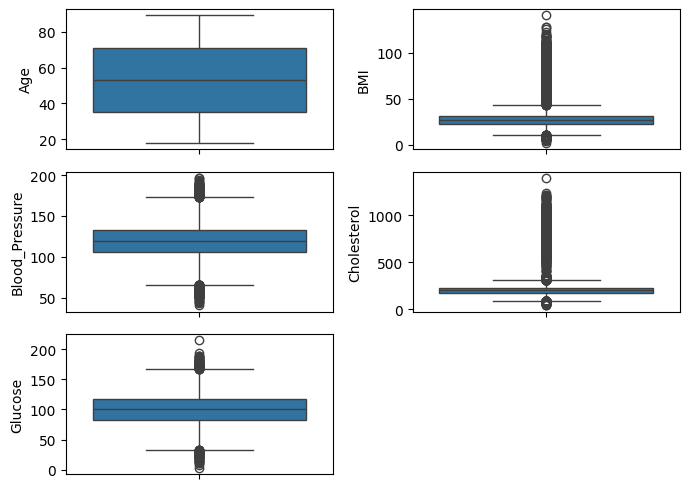

In [314]:
plt.figure(figsize=(7,5))
plt.subplot(3,2,1)
sns.boxplot(y=df['Age'])
plt.subplot(3,2,2)
sns.boxplot(y=df['BMI'])
plt.subplot(3,2,3)
sns.boxplot(y=df['Blood_Pressure'])
plt.subplot(3,2,4)
sns.boxplot(y=df['Cholesterol'])
plt.subplot(3,2,5)
sns.boxplot(y=df['Glucose'])
plt.tight_layout()
plt.show()

In [315]:
# Data preprocessing

In [316]:
# Handling missing values

In [317]:
df['Age']=df['Age'].fillna(df['Age'].median())
df['BMI']=df['BMI'].fillna(df['BMI'].median())
df['Glucose']=df['Glucose'].fillna(df['Glucose'].median())
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Smoking_Status']=df['Smoking_Status'].fillna(df['Smoking_Status'].mode()[0])
df['Physical_Activity']=df['Physical_Activity'].fillna(df['Physical_Activity'].mode()[0])

In [318]:
df.isnull().sum()

,0
Age,0
BMI,0
Blood_Pressure,0
Cholesterol,0
Glucose,0
Gender,0
Smoking_Status,0
Physical_Activity,0
Family_History,0
Disease_Risk,0


In [319]:
df.drop_duplicates()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose,Gender,Smoking_Status,Physical_Activity,Family_History,Disease_Risk
0,53.0,30.077885,134.747988,111.736421,100.242047,Male,Former,Low,No,Medium Risk
1,32.0,27.168528,121.306020,164.177518,100.242047,Female,Former,Low,Yes,Low Risk
2,53.0,27.168528,134.370880,647.207988,100.242047,Female,Former,Medium,No,Low Risk
3,78.0,27.168528,106.362616,152.720404,100.242047,Female,Current,Low,Yes,Medium Risk
4,38.0,33.664362,113.854555,257.503168,100.242047,Male,Former,Low,No,Medium Risk
...,...,...,...,...,...,...,...,...,...,...
49995,21.0,26.587148,149.243534,172.453516,100.242047,Female,Current,Low,Yes,Medium Risk
49996,35.0,27.168528,145.145817,192.961255,100.242047,Female,Never,Low,No,Low Risk
49997,46.0,28.381970,95.568962,175.396439,83.979295,Male,Former,Low,No,Low Risk
49998,56.0,27.176699,114.237839,154.908408,100.242047,Male,Former,Low,Yes,Medium Risk


In [320]:
# Outlier detecting using IQR method and Capping them
# BMI column
q1=df['BMI'].quantile(0.25)
q3=df['BMI'].quantile(0.75)
IQR=q3-q1

lower=q1-1.5*IQR
upper=q3+1.5*IQR
df['BMI']=df['BMI'].clip(lower,upper)

In [321]:
# Blood pressure column
q1=df['Blood_Pressure'].quantile(0.25)
q3=df['Blood_Pressure'].quantile(0.75)
IQR=q3-q1

lower=q1-1.5*IQR
upper=q3+1.5*IQR
df['Blood_Pressure']=df['Blood_Pressure'].clip(lower,upper)

In [322]:
# Cholesterol column
q1=df['Cholesterol'].quantile(0.25)
q3=df['Cholesterol'].quantile(0.75)
IQR=q3-q1

lower=q1-1.5*IQR
upper=q3+1.5*IQR
df['Cholesterol']=df['Cholesterol'].clip(lower,upper)

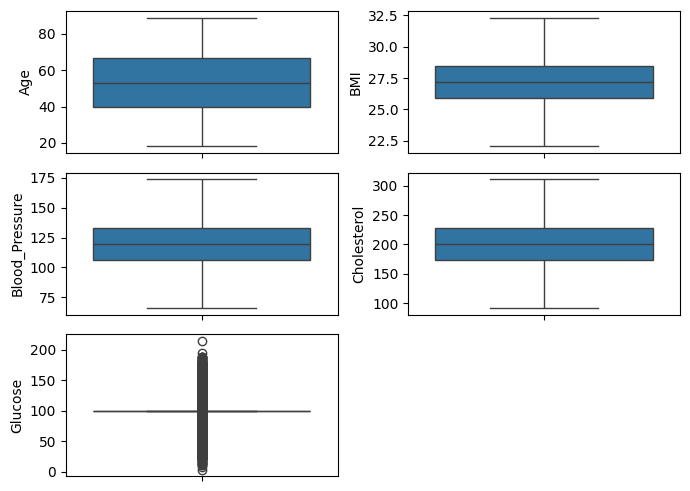

In [323]:
plt.figure(figsize=(7,5))
plt.subplot(3,2,1)
sns.boxplot(y=df['Age'])
plt.subplot(3,2,2)
sns.boxplot(y=df['BMI'])
plt.subplot(3,2,3)
sns.boxplot(y=df['Blood_Pressure'])
plt.subplot(3,2,4)
sns.boxplot(y=df['Cholesterol'])
plt.subplot(3,2,5)
sns.boxplot(y=df['Glucose'])
plt.tight_layout()
plt.show()

In [324]:
# Encoding Categorical features
df.select_dtypes(include='object').head(10)

,Gender,Smoking_Status,Physical_Activity,Family_History,Disease_Risk
0,Male,Former,Low,No,Medium Risk
1,Female,Former,Low,Yes,Low Risk
2,Female,Former,Medium,No,Low Risk
3,Female,Current,Low,Yes,Medium Risk
4,Male,Former,Low,No,Medium Risk
5,Male,Former,Low,No,Low Risk
6,Female,Never,Low,Yes,Medium Risk
7,Male,Never,Low,No,Low Risk
8,Male,Former,Low,Yes,Medium Risk
9,Male,Former,Low,No,Low Risk


In [325]:
# Physical activity is ordinal column
# Gender, Smoking status, Family History ae nominal columns
# Use label encoder for disease risk as it is the output column

import sklearn
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

ohe=OneHotEncoder(sparse_output=False)
oe=OrdinalEncoder()
le=LabelEncoder()

In [326]:
df['Physical_Activity']=oe.fit_transform(df[['Physical_Activity']])

In [327]:
nominal_cols=['Gender', 'Smoking_Status','Family_History']
encoded=ohe.fit_transform(df[nominal_cols])

In [328]:
encoded_df=pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols))
encoded_df

,Gender_Female,Gender_Male,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Family_History_No,Family_History_Yes
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...
50495,0.0,1.0,1.0,0.0,0.0,1.0,0.0
50496,0.0,1.0,0.0,0.0,1.0,0.0,1.0
50497,1.0,0.0,0.0,1.0,0.0,0.0,1.0
50498,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [329]:
df.drop(columns=nominal_cols, inplace=True)
df=pd.concat([df, encoded_df], axis=1)

In [330]:
df['Disease_Risk']=le.fit_transform(df[['Disease_Risk']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [331]:
df

,Age,BMI,Blood_Pressure,Cholesterol,Glucose,Physical_Activity,Disease_Risk,Gender_Female,Gender_Male,Smoking_Status_Current,Smoking_Status_Former,Smoking_Status_Never,Family_History_No,Family_History_Yes
0,53.0,30.077885,134.747988,111.736421,100.242047,1.0,2,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,32.0,27.168528,121.306020,164.177518,100.242047,1.0,1,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,53.0,27.168528,134.370880,311.020224,100.242047,2.0,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,78.0,27.168528,106.362616,152.720404,100.242047,1.0,2,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,38.0,32.330459,113.854555,257.503168,100.242047,1.0,2,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50495,47.0,27.168528,111.875095,184.264120,100.242047,1.0,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0
50496,79.0,22.028278,85.661939,200.712123,108.401004,2.0,2,0.0,1.0,0.0,0.0,1.0,0.0,1.0
50497,85.0,31.721577,126.445309,185.430410,100.242047,1.0,2,1.0,0.0,0.0,1.0,0.0,0.0,1.0
50498,74.0,29.395985,135.455047,233.879759,100.242047,1.0,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [334]:
from sklearn.preprocessing import StandardScaler
numerical_cols=['Age','BMI','Glucose', 'Blood_Pressure', 'Cholesterol']
df[numerical_cols]=StandardScaler().fit_transform(df[numerical_cols])

In [335]:
# Train test splitting
from sklearn.model_selection import train_test_split
x=df.drop(columns='Disease_Risk')
y=df['Disease_Risk']

In [336]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=23)

In [337]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [338]:
y_pred=knn.predict(x_test)

In [347]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [363]:
acc=accuracy_score(y_test, y_pred)
pre=precision_score(y_test,y_pred, average='weighted')
re=recall_score(y_test, y_pred, average='weighted')
f1=f1_score(y_test, y_pred, average='weighted')

In [364]:
print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", re)
print("F1 Score :", f1)
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.7441584158415842
Precision: 0.7424672862753154
Recall   : 0.7441584158415842
F1 Score : 0.7431958920840162

              precision    recall  f1-score   support

           0       0.42      0.33      0.37       159
           1       0.69      0.68      0.68      3807
           2       0.79      0.80      0.79      6134

    accuracy                           0.74     10100
   macro avg       0.63      0.60      0.62     10100
weighted avg       0.74      0.74      0.74     10100



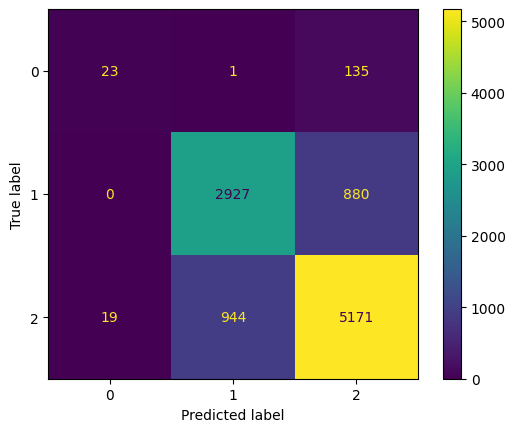

In [352]:
cm=confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

The KNN model achieved an accuracy of 80.4%, weighted precision of 80.1%, weighted recall of 80.4%, and weighted F1-score of 80.1%. The model performed well for Class 1 and Class 2, achieving F1-scores of 0.76 and 0.84 respectively.

In [357]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
gnb.fit(x_train, y_train)

GaussianNB()

In [358]:
y_pred=gnb.predict(x_test)

In [361]:
acc=accuracy_score(y_test, y_pred)
pre=precision_score(y_test,y_pred, average='weighted')
re=recall_score(y_test, y_pred, average='weighted')
f1=f1_score(y_test, y_pred, average='weighted')

In [362]:
print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", re)
print("F1 Score :", f1)
print()
print(classification_report(y_test, y_pred))

Accuracy : 0.7441584158415842
Precision: 0.7424672862753154
Recall   : 0.7441584158415842
F1 Score : 0.7431958920840162

              precision    recall  f1-score   support

           0       0.42      0.33      0.37       159
           1       0.69      0.68      0.68      3807
           2       0.79      0.80      0.79      6134

    accuracy                           0.74     10100
   macro avg       0.63      0.60      0.62     10100
weighted avg       0.74      0.74      0.74     10100



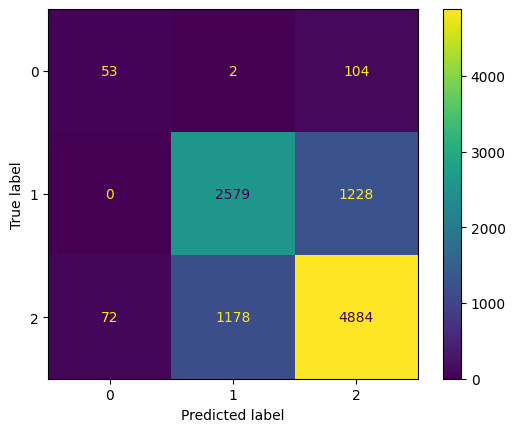

In [365]:
cm=confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

KNN outperformed Gaussian Naive Bayes with an accuracy of 80.4% compared to 74.4%. KNN achieved superior precision, recall, and F1-score on the majority classes. Overall, KNN was selected as the preferred model due to its higher overall predictive performance.